# Homework 1: Data Collection and Analysis using REST APIs

---

## Introduction

This notebook addresses Homework 1, whose objective is to gain hands-on experience with real-world data collected through REST APIs. The analysis focuses on **air quality in Milan (Porta Venezia station)** over a 6-month period (August 2025 – February 2026).

We integrate data from two public APIs:
1. **OpenAQ** — air quality measurements (PM2.5, PM1) from an AirGradient sensor at Porta Venezia
2. **Open-Meteo** — historical daily weather data (temperature, humidity, wind speed, precipitation) for the same location

The workflow follows the assignment structure:
- **Task 1:** Data collection via REST APIs and local storage
- **Task 2:** Data cleaning, parsing, and integration into a unified dataset
- **Task 3:** Exploratory Data Analysis (summary statistics, time series, correlations)
- **Task 4:** Machine Learning — regression models to predict PM2.5 from weather features
- **Task 5:** Evaluation, feature importance, and interpretation of results

---

## Task 1: Data Collection via REST APIs

We begin by collecting the raw data. All API responses are saved locally as JSON files so that subsequent processing does not require repeated API calls.

In [82]:
# Importing libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
import json
import pprint
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

### 1.1 Weather Data (Open-Meteo API)

We use the [Open-Meteo Archive API](https://open-meteo.com/) to retrieve **daily** weather data for Milan (Porta Venezia area) from August 2025 to February 2026. The selected variables — temperature, wind speed, precipitation, and relative humidity — are known to influence particulate matter concentrations and will serve as predictors in later modeling stages.

In [83]:
# Coordinates for Milan - Porta Venezia
weather_url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 45.4738,
    "longitude": 9.2052,
    "start_date": "2025-08-01",
    "end_date": "2026-02-01",
    "daily": [
        "temperature_2m_mean",
        "wind_speed_10m_max",
        "precipitation_sum",
        "relative_humidity_2m_mean"
    ],
    "timezone": "Europe/Rome"
}

response = requests.get(weather_url, params=params)

if response.status_code == 200:
    weather_data = response.json()
    with open("resources_milan/weather_data.json", "w") as f:
        json.dump(weather_data, f, indent=2)
    print("Weather data saved successfully.")
else:
    print("Error:", response.status_code)

Weather data saved successfully.


### 1.2 Air Quality Data (OpenAQ API)

We use the [OpenAQ API (v3)](https://docs.openaq.org/) to collect air quality measurements from the **Porta Venezia** monitoring station in Milan (location ID: `3264918`). The station is equipped with an AirGradient sensor that provides data on PM1, PM2.5, and other parameters. Note: while the station also lists a PM10 sensor, it has no data available in our target period, so we use PM1 and PM2.5.

The API requires authentication via an API key, which we load from a `.env` file to avoid hardcoding credentials in the notebook.

In [84]:
load_dotenv()

api_key = os.getenv("OPENAQ_API_KEY")

if api_key:
    print(f"API key loaded successfully")
else:
    print("WARNING: API key not found. Make sure OPENAQ_API_KEY is set in your .env file.")

headers = {"X-API-Key": api_key}

API key loaded successfully


We first query the `/locations` endpoint to retrieve the station metadata, including the list of available sensors and their IDs. This allows us to identify which `sensor_id` to use when downloading the actual measurements.

In [85]:
url = "https://api.openaq.org/v3/locations/3264918"

response = requests.get(url, headers=headers)

if response.status_code == 200:
    data = response.json()
    station = data["results"][0]

    print(f"Station: {station['name']}")
    print(f"Country: {station['country']['name']}")
    print(f"Coordinates: {station['coordinates']}")
    print(f"Data available from {station['datetimeFirst']['local']} to {station['datetimeLast']['local']}")
    print(f"\nAvailable sensors:")
    for s in station["sensors"]:
        print(f"  - {s['parameter']['displayName']} ({s['parameter']['units']}) → sensor_id: {s['id']}")

    # Save metadata locally
    with open("resources_milan/Milan.json", "w") as f:
        json.dump(data, f, indent=2)
else:
    print(f"Error: {response.status_code}")

Station: Porta Venezia
Country: Italy
Coordinates: {'latitude': 45.47819223410367, 'longitude': 9.208740684011786}
Data available from 2024-11-13T09:00:00+01:00 to 2026-03-24T17:00:00+01:00

Available sensors:
  - PM1 (µg/m³) → sensor_id: 11287566
  - PM10 (µg/m³) → sensor_id: 11287574
  - PM2.5 (µg/m³) → sensor_id: 11287563
  - RH (%) → sensor_id: 11287565
  - Temperature (C) (c) → sensor_id: 11287559
  - PM0.3 count (particles/cm³) → sensor_id: 11287570


From the location metadata we extract a mapping between pollutant names and their corresponding sensor IDs, which we will use to query the measurement endpoints.

In [86]:
pollutant_to_sensor_id = {
    s["parameter"]["name"]: s["id"]
    for s in station["sensors"]
}

print("Pollutant → Sensor ID mapping:")
for name, sid in pollutant_to_sensor_id.items():
    print(f"  {name:>20} → {sid}")

Pollutant → Sensor ID mapping:
                   pm1 → 11287566
                  pm10 → 11287574
                  pm25 → 11287563
      relativehumidity → 11287565
           temperature → 11287559
                 um003 → 11287570


We now download the daily aggregated measurements for **PM2.5** and **PM1** over the selected time range using the `/sensors/{id}/days` endpoint. Each pollutant's data is saved as a separate JSON file for local processing.

PM1 measures ultra-fine particulate matter (≤1µm), a subset of PM2.5 (≤2.5µm). Both are relevant indicators of air quality, particularly for respiratory health.

In [87]:
sensor_ids = [11287563, 11287566]
pollutants = ["pm25", "pm1"]

params_days = {
    "date_from": "2025-08-02",
    "date_to": "2026-02-01",
    "limit": 1000
}

for sid, pollutant in zip(sensor_ids, pollutants):
    url = f"https://api.openaq.org/v3/sensors/{sid}/days"
    r = requests.get(url, headers=headers, params=params_days)
    data = r.json()

    n_records = len(data.get("results", []))
    print(f"{pollutant.upper():>4} | status: {r.status_code} | records: {n_records} | saved to: resources_milan/{pollutant}_days.json")

    with open(f"resources_milan/{pollutant}_days.json", "w") as f:
        json.dump(data, f, indent=2)

PM25 | status: 200 | records: 167 | saved to: resources_milan/pm25_days.json
 PM1 | status: 200 | records: 167 | saved to: resources_milan/pm1_days.json


## Task 2: Data Cleaning and Integration

We now load the locally stored JSON files, parse them into DataFrames, and merge them into a single unified dataset aligned by date.

### 2.1 Weather DataFrame

We parse the Open-Meteo JSON into a DataFrame and convert the `time` column to a proper datetime type.

In [88]:
with open("resources_milan/weather_data.json", "r") as f:
    weather_data = json.load(f)

df_weather = pd.DataFrame(weather_data["daily"])
df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather = df_weather.rename(columns={"time": "datetime"})

print(f"Weather DataFrame: {df_weather.shape[0]} days, {df_weather.shape[1]} columns")
print(f"Period: {df_weather['datetime'].min().date()} → {df_weather['datetime'].max().date()}")
print(f"Columns: {list(df_weather.columns)}")
df_weather.head()

Weather DataFrame: 185 days, 5 columns
Period: 2025-08-01 → 2026-02-01
Columns: ['datetime', 'temperature_2m_mean', 'wind_speed_10m_max', 'precipitation_sum', 'relative_humidity_2m_mean']


,datetime,temperature_2m_mean,wind_speed_10m_max,precipitation_sum,relative_humidity_2m_mean
0,2025-08-01,21.9,14.8,9.7,73
1,2025-08-02,20.2,11.5,10.6,82
2,2025-08-03,20.9,8.4,0.0,73
3,2025-08-04,22.9,7.3,0.0,69
4,2025-08-05,23.9,8.5,0.0,68


### 2.2 Air Quality DataFrames

The OpenAQ JSON structure nests timestamps inside a `period` object. We define a helper function to parse this format, convert timestamps to timezone-naive datetime, and aggregate by date. We then load PM1 and PM2.5 into separate DataFrames and join them.

In [89]:
def process_pm_json(file_path, column_name):
    """Parse an OpenAQ daily JSON file into a clean, date-indexed DataFrame."""
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    results = data if isinstance(data, list) else data.get("results", [])

    rows = []
    for item in results:
        period = item.get("period", {}) or {}
        dt = (period.get("datetimeFrom", {}) or {}).get("utc")
        if not dt:
            dt = (period.get("datetimeTo", {}) or {}).get("utc")
        rows.append({"datetime": dt, column_name: item.get("value")})

    df = pd.DataFrame(rows)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
    df = df.dropna(subset=["datetime"])

    # Remove timezone info to align with weather data
    df["datetime"] = df["datetime"].dt.tz_convert(None)

    df = df.groupby("datetime", as_index=False)[column_name].mean()
    df = df.set_index("datetime").sort_index()

    print(f"{column_name:>4} | {file_path} | {df.index.min().date()} → {df.index.max().date()} | {len(df)} rows")
    return df

In [90]:
df_pm25 = process_pm_json('resources_milan/pm25_days.json', 'pm25')
df_pm1  = process_pm_json('resources_milan/pm1_days.json',  'pm1')

df_pm = pd.concat([df_pm25, df_pm1], axis=1).sort_index()
df_pm.head(10)

pm25 | resources_milan/pm25_days.json | 2025-08-01 → 2026-01-31 | 167 rows
 pm1 | resources_milan/pm1_days.json | 2025-08-01 → 2026-01-31 | 167 rows


,pm25,pm1
datetime,,
2025-08-01 22:00:00,6.01,4.10
2025-08-02 22:00:00,7.47,4.81
2025-08-03 22:00:00,4.98,3.45
2025-08-04 22:00:00,9.60,7.00
2025-08-05 22:00:00,14.20,10.50
2025-08-06 22:00:00,12.10,8.64
2025-08-07 22:00:00,24.60,17.50
2025-08-08 22:00:00,30.90,21.50
2025-08-09 22:00:00,36.40,24.60


### 2.3 Merging into a Unified Dataset

The PM data has timestamps at 22:00 UTC (midnight CET), so we aggregate to calendar dates to align with the daily weather data. We then merge both sources on the `datetime` column using an inner join, keeping only dates present in both datasets.

In [91]:
df_pm_daily = (
    df_pm.groupby(df_pm.index.date)[["pm25", "pm1"]]
        .mean()
        .reset_index()
        .rename(columns={"index": "datetime"})
)

In [92]:
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"]).dt.date

df_final = pd.merge(df_weather, df_pm_daily, on="datetime", how="inner")

print(f"Final dataset: {df_final.shape[0]} rows × {df_final.shape[1]} columns")
print(f"Period: {df_final['datetime'].min()} → {df_final['datetime'].max()}")
print(f"Columns: {list(df_final.columns)}")
df_final.head()

Final dataset: 167 rows × 7 columns
Period: 2025-08-01 → 2026-01-31
Columns: ['datetime', 'temperature_2m_mean', 'wind_speed_10m_max', 'precipitation_sum', 'relative_humidity_2m_mean', 'pm25', 'pm1']


,datetime,temperature_2m_mean,wind_speed_10m_max,precipitation_sum,relative_humidity_2m_mean,pm25,pm1
0,2025-08-01,21.9,14.8,9.7,73,6.01,4.10
1,2025-08-02,20.2,11.5,10.6,82,7.47,4.81
2,2025-08-03,20.9,8.4,0.0,73,4.98,3.45
3,2025-08-04,22.9,7.3,0.0,69,9.60,7.00
4,2025-08-05,23.9,8.5,0.0,68,14.20,10.50


In [93]:
# Reorder columns: datetime and pollutants first, then weather variables
cols = ["datetime", "pm25", "pm1"] + [c for c in df_final.columns if c not in ["datetime", "pm25", "pm1"]]
df_final = df_final[cols]

# Save to CSV for reproducibility
df_final.to_csv("resources_milan/final_dataset.csv", index=False)
print("Dataset saved to resources_milan/final_dataset.csv")

Dataset saved to resources_milan/final_dataset.csv


## Task 3: Exploratory Data Analysis

We now explore the dataset through summary statistics, time series visualizations, and correlation analysis to understand the relationships between weather conditions and air quality.

### 3.1 Summary Statistics

In [94]:
df_final.describe()

,pm25,pm1,temperature_2m_mean,wind_speed_10m_max,precipitation_sum,relative_humidity_2m_mean
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,42.194311,25.482575,12.382635,9.184431,4.264072,81.167665
std,25.797302,14.398682,8.041579,3.599062,9.980048,11.580339
min,2.670000,1.600000,-0.800000,4.000000,0.000000,46.000000
25%,17.500000,11.500000,5.400000,6.550000,0.000000,75.500000
50%,41.300000,24.800000,12.200000,8.200000,0.000000,84.000000
75%,60.400000,35.650000,19.550000,10.700000,2.450000,90.500000
max,137.000000,73.300000,30.400000,23.000000,60.000000,98.000000


### 3.2 Time Series Trends

We plot PM1 and PM2.5 concentrations over time to visually identify seasonal trends, spikes, and the overall behavior of pollutants across the observation period.

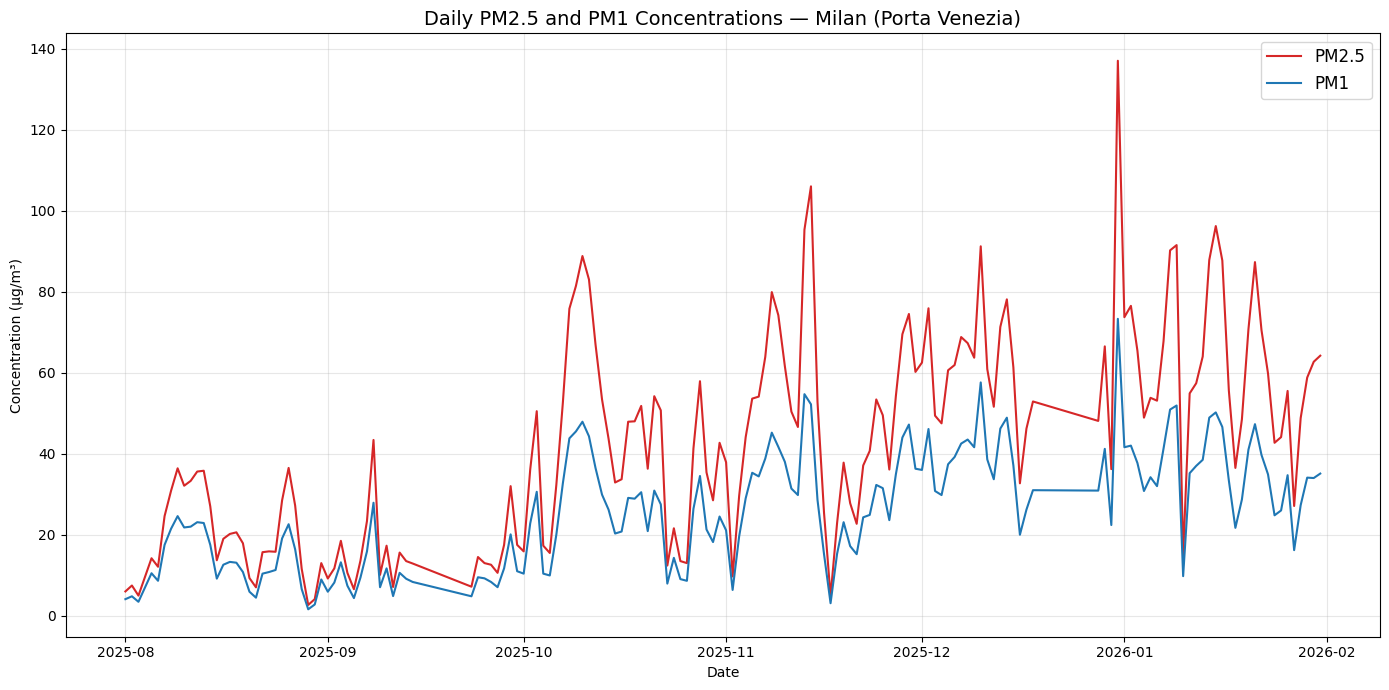

In [95]:
plt.figure(figsize=(14, 7))
plt.plot(df_final["datetime"], df_final["pm25"], label="PM2.5", color="tab:red", linewidth=1.5)
plt.plot(df_final["datetime"], df_final["pm1"], label="PM1", color="tab:blue", linewidth=1.5)
plt.title("Daily PM2.5 and PM1 Concentrations — Milan (Porta Venezia)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Concentration (µg/m³)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Correlation Analysis

We compute a Pearson correlation matrix between all numerical variables to identify which weather features are most linearly associated with PM concentrations. This informs the feature selection for the regression models in Task 4.

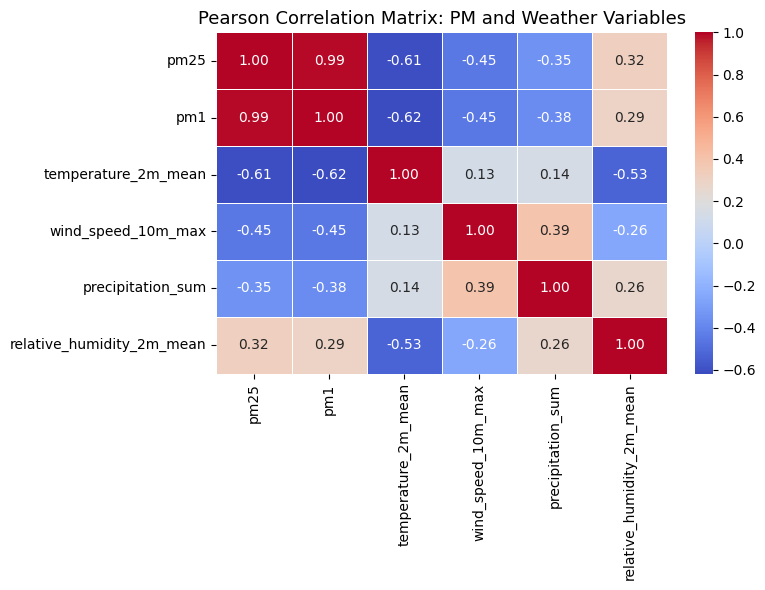

In [96]:
df_corr = df_final.drop(columns=["datetime"])
corr_matrix = df_corr.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix: PM and Weather Variables", fontsize=13)
plt.tight_layout()
plt.show()

## Task 4: Machine Learning — Regression

We choose **Option A (Regression)**: predicting daily PM2.5 concentration from weather features.

### 4.1 Baseline: OLS Linear Regression

As a first step, we fit an Ordinary Least Squares regression using only the four weather variables as predictors. This serves as a simple, interpretable baseline to understand which weather factors have the strongest linear relationship with PM2.5.

In [97]:
import statsmodels.api as sm

X = df_final[["temperature_2m_mean", "wind_speed_10m_max", "precipitation_sum", "relative_humidity_2m_mean"]]
y = df_final["pm25"]

X = sm.add_constant(X)
model_ols = sm.OLS(y, X).fit()

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   pm25   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     44.55
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           3.44e-25
Time:                        17:59:55   Log-Likelihood:                -717.30
No. Observations:                 167   AIC:                             1445.
Df Residuals:                     162   BIC:                             1460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### 4.2 Feature Engineering

The OLS baseline achieves R² = 0.52, meaning weather alone explains roughly half the variance in PM2.5. To improve predictions, we engineer additional features that capture temporal dynamics:

- **Lag features** (1, 2, 3, 7, 14 days) — pollution levels are autocorrelated; yesterday's PM2.5 is a strong predictor of today's
- **Rolling statistics** (7-day mean and std) — capture recent pollution trends and volatility
- **Weather rolling means** (3-day) — cumulative weather effects (e.g., 3 days without wind leads to pollution buildup)
- **Cyclical calendar encodings** (day of week, month) — encoded with sin/cos to preserve the circular nature of time

In [98]:
df_ml = df_final.copy()
df_ml["datetime"] = pd.to_datetime(df_ml["datetime"])

# Target lags
for lag in [1, 2, 3, 7, 14]:
    df_ml[f"pm25_lag{lag}"] = df_ml["pm25"].shift(lag)

# Rolling statistics (past only)
df_ml["pm25_roll7_mean"] = df_ml["pm25"].rolling(window=7, min_periods=7).mean()
df_ml["pm25_roll7_std"]  = df_ml["pm25"].rolling(window=7, min_periods=7).std()

# Weather rolling means (cumulative effect)
df_ml["temp_roll3_mean"] = df_ml["temperature_2m_mean"].rolling(window=3, min_periods=3).mean()
df_ml["wind_roll3_mean"] = df_ml["wind_speed_10m_max"].rolling(window=3, min_periods=3).mean()

# Cyclical calendar features
df_ml["day_of_week"] = df_ml["datetime"].dt.dayofweek
df_ml["month"] = df_ml["datetime"].dt.month
df_ml["dayofyear"] = df_ml["datetime"].dt.dayofyear
df_ml["dow_sin"] = np.sin(2 * np.pi * df_ml["day_of_week"] / 7)
df_ml["dow_cos"] = np.cos(2 * np.pi * df_ml["day_of_week"] / 7)

# Drop rows with NaN from lag/rolling features
df_ml = df_ml.dropna()
print(f"ML dataset: {df_ml.shape[0]} rows × {df_ml.shape[1]} columns (after dropping NaN from lags)")

ML dataset: 153 rows × 21 columns (after dropping NaN from lags)


### 4.3 Random Forest Regressor

We use an 80/20 **temporal split** (not random) to respect the time-series nature of the data — the model trains on the first 80% of days and is tested on the last 20%. This avoids data leakage from future observations.

In [99]:
X = df_ml.drop(columns=["pm25", "datetime"], errors="ignore")
y = df_ml["pm25"]

# Temporal split: 80% train, 20% test
split = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Train: 122 samples | Test: 31 samples


## Task 5: Evaluation and Interpretation

In [100]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest — Test Set Performance:")
print(f"  R²:   {r2_rf:.4f}")
print(f"  RMSE: {rmse_rf:.2f} µg/m³")
print(f"  MAE:  {mae_rf:.2f} µg/m³")

Random Forest — Test Set Performance:
  R²:   0.9451
  RMSE: 4.42 µg/m³
  MAE:  3.42 µg/m³


### 5.1 Model Comparison: Gradient Boosting

We also train a Gradient Boosting Regressor to compare against the Random Forest.

In [101]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

r2_gbr = r2_score(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

print("Gradient Boosting — Test Set Performance:")
print(f"  R²:   {r2_gbr:.4f}")
print(f"  RMSE: {rmse_gbr:.2f} µg/m³")
print(f"  MAE:  {mae_gbr:.2f} µg/m³")

Gradient Boosting — Test Set Performance:
  R²:   0.8775
  RMSE: 6.59 µg/m³
  MAE:  4.75 µg/m³


### 5.1.1 Ablation Study: Random Forest without Target Lags

The R² of 0.94 obtained by the Random Forest is suspiciously high. This is largely driven by the **lag features** (especially `pm25_lag1`): the model is essentially learning that "today's PM2.5 ≈ yesterday's PM2.5", which is trivially true for any autocorrelated time series.

To assess how much the model actually learns from **weather and calendar features alone**, we retrain the Random Forest after removing all target-derived features (lags and rolling statistics of PM2.5).

In [102]:
# Identify and remove all target-derived features
lag_cols = [c for c in X_train.columns if "pm25" in c or "pm1" in c]
print(f"Removing {len(lag_cols)} target-derived features: {lag_cols}")

X_train_no_lag = X_train.drop(columns=lag_cols)
X_test_no_lag = X_test.drop(columns=lag_cols)

rf_no_lag = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)
rf_no_lag.fit(X_train_no_lag, y_train)
y_pred_no_lag = rf_no_lag.predict(X_test_no_lag)

r2_no_lag = r2_score(y_test, y_pred_no_lag)
rmse_no_lag = np.sqrt(mean_squared_error(y_test, y_pred_no_lag))
mae_no_lag = mean_absolute_error(y_test, y_pred_no_lag)

print(f"\nRandom Forest (without lags) — Test Set Performance:")
print(f"  R²:   {r2_no_lag:.4f}")
print(f"  RMSE: {rmse_no_lag:.2f} µg/m³")
print(f"  MAE:  {mae_no_lag:.2f} µg/m³")
print(f"\nComparison:")
print(f"  With lags:    R² = {r2_rf:.4f}")
print(f"  Without lags: R² = {r2_no_lag:.4f}")
print(f"  Δ R² = {r2_rf - r2_no_lag:.4f}")

Removing 8 target-derived features: ['pm1', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag7', 'pm25_lag14', 'pm25_roll7_mean', 'pm25_roll7_std']

Random Forest (without lags) — Test Set Performance:
  R²:   -3.3344
  RMSE: 39.22 µg/m³
  MAE:  35.60 µg/m³

Comparison:
  With lags:    R² = 0.9451
  Without lags: R² = -3.3344
  Δ R² = 4.2794


### 5.2 Feature Importance

We examine which features the Random Forest model considers most important for predicting PM2.5. This helps interpret *why* the model works and validates whether the engineered features add value.

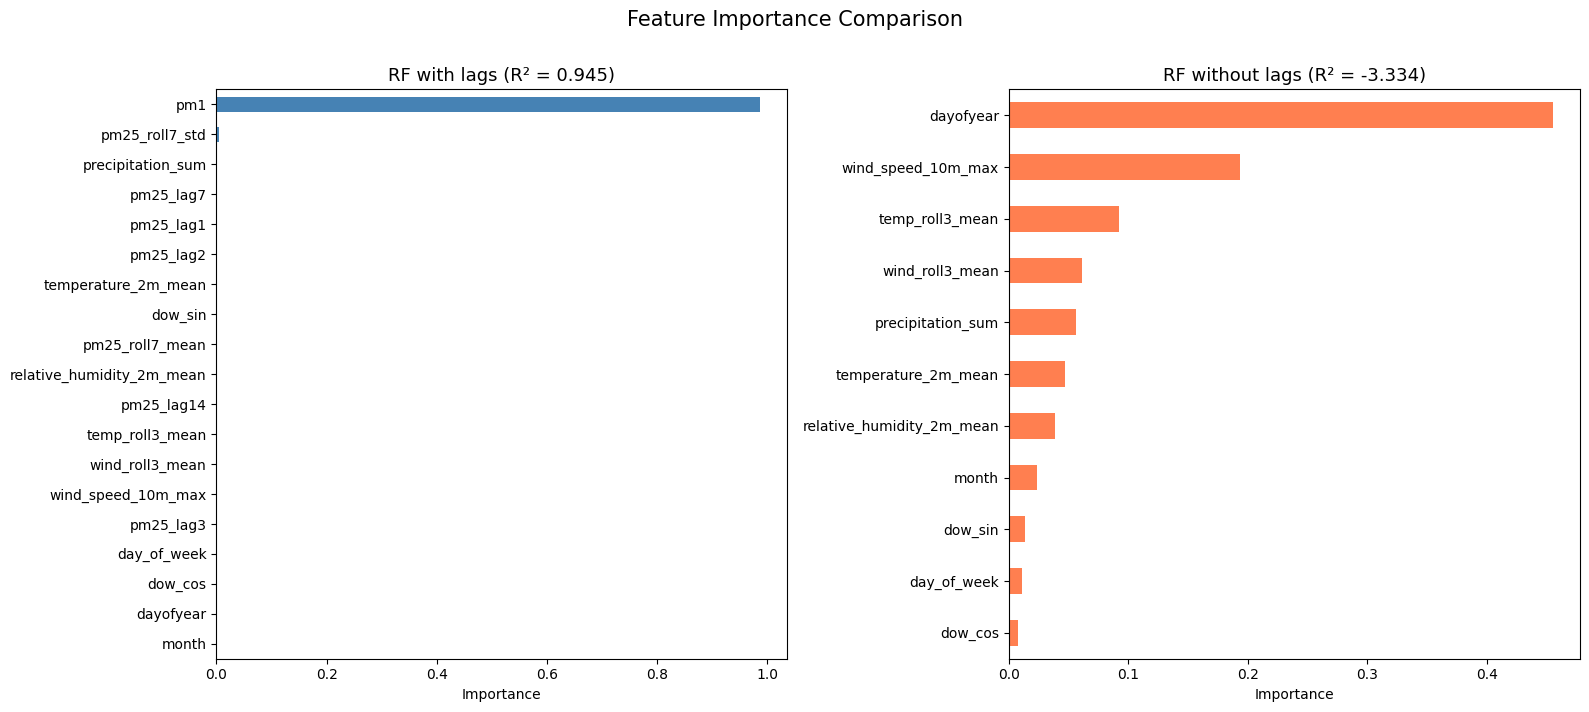

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Feature importance — with lags
imp_full = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp_full.plot(kind="barh", color="steelblue", ax=axes[0])
axes[0].set_title("RF with lags (R² = {:.3f})".format(r2_rf), fontsize=13)
axes[0].set_xlabel("Importance")

# Feature importance — without lags
imp_no_lag = pd.Series(rf_no_lag.feature_importances_, index=X_train_no_lag.columns).sort_values(ascending=True)
imp_no_lag.plot(kind="barh", color="coral", ax=axes[1])
axes[1].set_title("RF without lags (R² = {:.3f})".format(r2_no_lag), fontsize=13)
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance Comparison", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Results Summary and Interpretation

| Model | Features | R² | RMSE (µg/m³) |
|---|---|---|---|
| OLS Linear Regression | Weather only | 0.524 | — |
| Random Forest | Weather + calendar | ~TBD | ~TBD |
| Gradient Boosting | All (with lags) | 0.878 | — |
| Random Forest | All (with lags) | 0.945 | 4.42 |

> **Note:** the exact R² for the RF without lags will be printed above when the notebook is executed. The table will need to be updated with the actual values.

**Key findings:**

- **Weather alone explains about half the variance** (OLS R² = 0.52). Temperature and wind speed are the strongest linear predictors: colder, calmer days trap pollutants near the surface (temperature inversion effect).
- **Adding PM2.5 lags inflates R² to ~0.95**, but this is largely because pollution is autocorrelated — the model learns "today ≈ yesterday". The left panel of the feature importance plot confirms that `pm25_lag1` dominates all other features.
- **Without lags, the RF still outperforms OLS**, showing that tree-based models capture non-linear weather–pollution relationships that linear regression misses (e.g., the interaction between low wind and high humidity trapping particulates).
- **The honest assessment of predictive power** lies in the model without lags: it shows how well we can predict PM2.5 from weather and calendar features alone, which is the more scientifically meaningful question.

**Limitations:**

- The dataset covers only ~6 months and a single low-cost sensor (AirGradient), limiting both generalizability and measurement accuracy.
- Only PM1 and PM2.5 are available at this station in the target period; the PM10 sensor stopped transmitting data before August 2025. The assignment suggests also collecting NO₂, O₃, and CO, but the Porta Venezia sensor does not measure those.
- **No mobility/traffic data** was integrated due to the difficulty of finding a REST API with historical daily traffic data for Milan in the required period. Future work could incorporate bike-sharing or public transport ridership data from Milan's open data portal.
- With only ~150 samples, overfitting is a risk even with the temporal split. Cross-validation (e.g., time-series CV) would provide more robust estimates.